In [9]:
# Ensure you have at least 2GB free space in Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project setup
import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

# Install dependencies
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working in: /content/drive/MyDrive/DL_Group_MGI1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 41.9 MB/s eta 0:00:00


In [27]:
# Run this everytime you update something in the repo!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

# if project directory is empty clone the repo, otherwise pull the latest changes
if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 282 bytes | 4.00 KiB/s, done.
From https://github.com/gabrielcastrob/Deep_learning_WUR
   c6de0bc..1b59de4  main       -> origin/main
Updating c6de0bc..1b59de4
error: invalid object 100644 c1e02d13034ebaf53a2dcd0806c460a5d3aad224 for 'GRS_34806_MGI_Project.ipynb'
Fast-forward
 utils.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [28]:
import importlib
import pandas as pd



# utility functions
import utils
# After git pull, reload utils to get the latest changes without restarting the notebook
importlib.reload(utils)

/content/drive/MyDrive/DL_Group_MGI1/utils.py:26: SyntaxWarning: invalid escape sequence '\L'
  IMAGE\LABEL   airplane   bare-soil   buildings   …   water


<module 'utils' from '/content/drive/MyDrive/DL_Group_MGI1/utils.py'>

In [11]:
Model_R = "ResNet50"
Model_V = "ViTB16"
classes = ['airplane','bare-soil','buildings','cars','chaparral','court','dock','field',
            'grass','mobile-home','pavement','sand','sea','ship','tanks','trees','water']

In [12]:
# load the probs preds and labels
output_df_R = pd.read_csv(f"outputs/{Model_R}_multilabel_test_results.csv")
test_preds_R = output_df_R[[f"{c}_pred" for c in classes]].values
test_labels_R = output_df_R[[f"{c}_label" for c in classes]].values
test_probs_R = output_df_R[[f"{c}_prob" for c in classes]].values

output_df_V = pd.read_csv(f"outputs/{Model_V}_multilabel_test_results.csv")
test_preds_V = output_df_V[[f"{c}_pred" for c in classes]].values
test_labels_V = output_df_V[[f"{c}_label" for c in classes]].values
test_probs_V = output_df_V[[f"{c}_prob" for c in classes]].values


# Calcualte the n for each class 
class_counts_R = test_labels_R.sum(axis=0)
class_counts_V = test_labels_V.sum(axis=0)

class_counts_R == class_counts_V

class_counts_df = pd.DataFrame({
    "Class": classes,
    "Count": class_counts_R,})


Saved F1 comparison plot to: outputs/model_comparison_f1.png


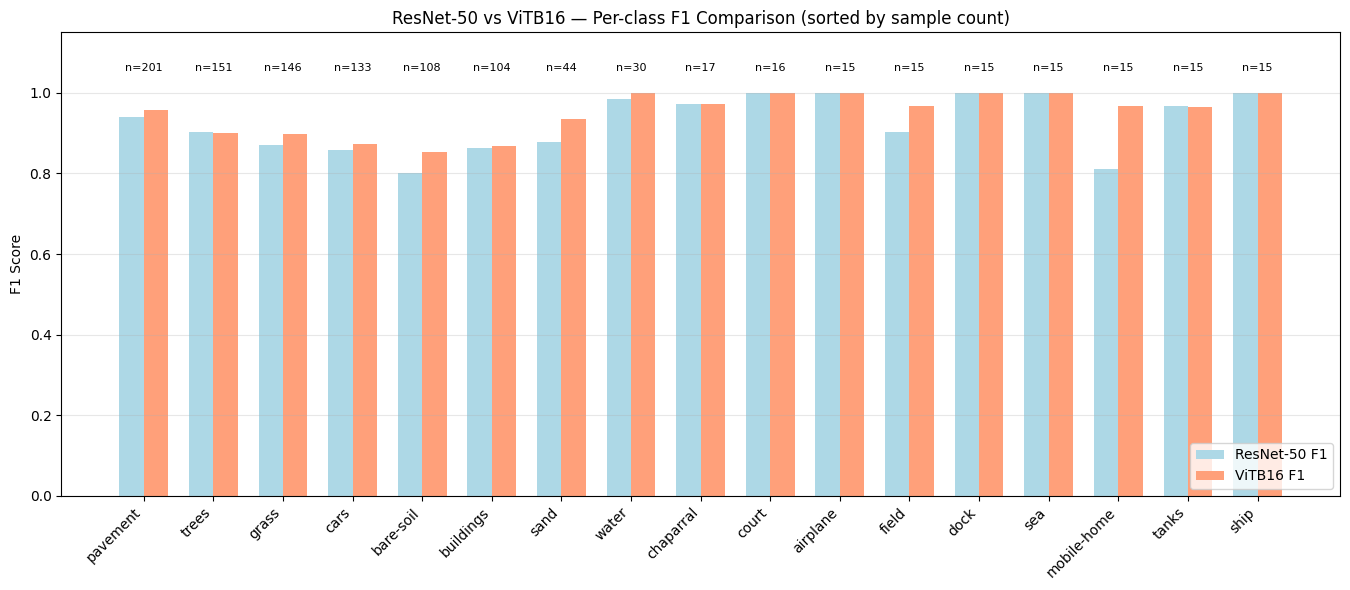

Saved AP comparison plot to: outputs/model_comparison_ap.png


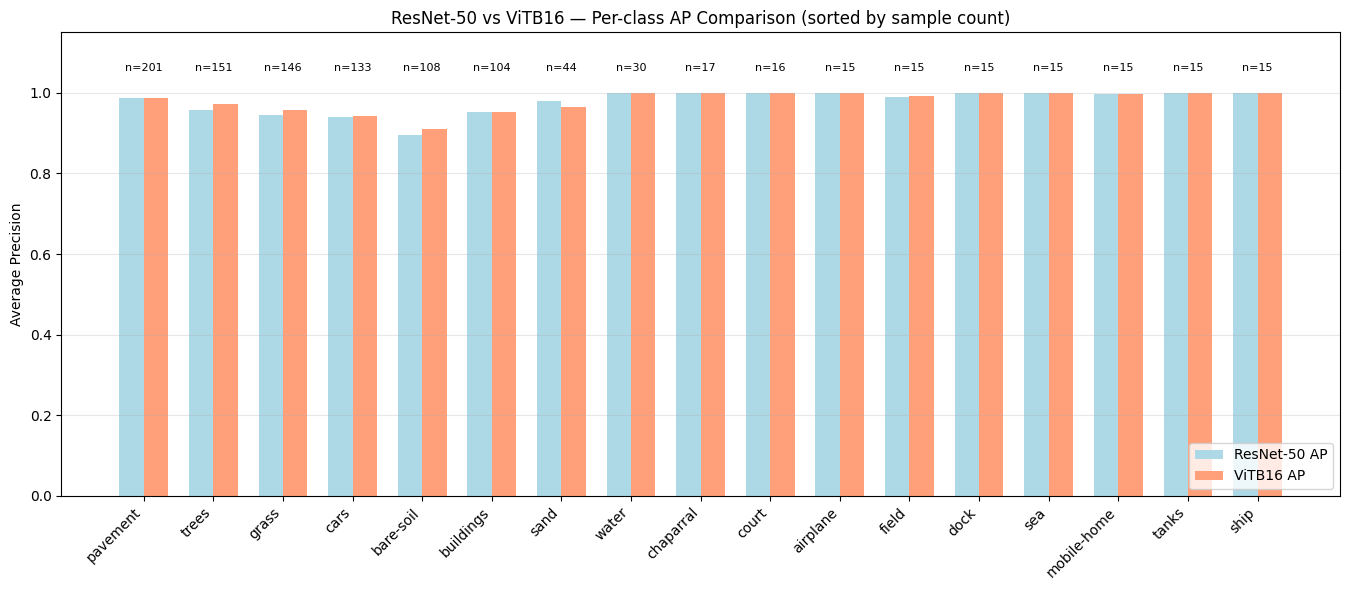

In [29]:
from utils import plot_per_class_metrics_comparison
fig_f1, ax_f1, fig_ap, ax_ap = plot_per_class_metrics_comparison(
    test_labels_R, test_preds_R, test_probs_R,
    test_labels_V, test_preds_V, test_probs_V,
    class_counts_df,
    model_name1="ResNet-50",
    model_name2="ViTB16",
    save_path="outputs/model_comparison.png")